# 03 — Uji Coba Model (3 Fitur: Accel + Gyro + BPM)

**Prasyarat:** `models/knn_model.pkl`, `models/scaler.pkl`, `models/bpm_medians.pkl` harus ada.
Jalankan `02_training_model.ipynb` terlebih dahulu untuk melatih dan menyimpan model.

**Catatan:** Dataset berasal dari `collect_participants.py` dengan pelabelan manual per sesi.
Setiap baris dataset memiliki kolom `activity` yang diisi operator, bukan dari ESP32.


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, StratifiedKFold

from config import FEATURES, TARGET, CLASSES, MODEL_PATH, SCALER_PATH, BPM_MED_PATH
from utils  import load_and_clean_dataset, impute_bpm, remove_outliers,\
                   normalize_features, encode_labels, impute_bpm_single, get_logger

logger = get_logger('notebook_03')
sns.set_theme(style='whitegrid')
print('Fitur:', FEATURES)

Fitur: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Load Model, Scaler, BPM Medians

In [2]:
model       = joblib.load(MODEL_PATH)
scaler      = joblib.load(SCALER_PATH)
bpm_medians = joblib.load(BPM_MED_PATH)

print(f'✅ Model   : K={model.n_neighbors}, metric={model.metric}, weights={model.weights}')
print(f'✅ Fitur   : {FEATURES}')
print(f'✅ BPM med : {bpm_medians}')

✅ Model   : K=18, metric=euclidean, weights=distance
✅ Fitur   : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
✅ BPM med : {'DUDUK': 80, 'BERJALAN': 86, 'BERLARI': 130, '_global': 93}


## 2. Prediksi Manual — Simulasi Nilai Sensor

Masukkan nilai `accel_stddev` (g), `gyro_stddev` (°/s), dan `BPM` untuk verifikasi model.
BPM = 0 akan diimputasi otomatis dengan median dari data training.

| Aktivitas  | accel_stddev (g) | gyro_stddev (°/s) | BPM (0=imputasi) |
|------------|-----------------|-------------------|------------------|
| DUDUK      | < 0.035         | < 10              | ~72              |
| BERJALAN   | 0.035 – 0.130   | 10 – 40           | ~95              |
| BERLARI    | ≥ 0.130         | ≥ 40              | ~145             |


In [3]:
def predict_activity(accel_std, gyro_std, bpm):
    """Prediksi dengan imputasi BPM otomatis jika bpm=0."""
    bpm_filled = impute_bpm_single(bpm, bpm_medians=bpm_medians)
    X = np.array([[accel_std, gyro_std, bpm_filled]])
    X_scaled = scaler.transform(X)
    pred  = model.predict(X_scaled)[0]
    proba = model.predict_proba(X_scaled)[0]
    return {
        'prediction':    pred,
        'confidence':    round(float(np.max(proba)), 4),
        'bpm_used':      int(bpm_filled),
        'probabilities': dict(zip(model.classes_, proba.round(4)))
    }

# Test cases: (accel, gyro, bpm, expected)
test_cases = [
    (0.010,  3.0,  70, 'DUDUK'),
    (0.020,  7.0,   0, 'DUDUK'),     # BPM=0 → diimputasi
    (0.070, 20.0,  90, 'BERJALAN'),
    (0.110, 35.0,   0, 'BERJALAN'),  # BPM=0 → diimputasi
    (0.200, 60.0, 140, 'BERLARI'),
    (0.350, 120.0,  0, 'BERLARI'),   # BPM=0 → diimputasi
]

print(f'{"accel":>8} {"gyro":>8} {"bpm":>5} {"bpm_used":>9} {"expected":>10} {"predicted":>10} {"conf":>8} {"OK?":>5}')
print('─'*72)
all_ok = True
for accel, gyro, bpm, expected in test_cases:
    r  = predict_activity(accel, gyro, bpm)
    ok = '✅' if r['prediction']==expected else '❌'
    if r['prediction']!=expected: all_ok=False
    print(f'{accel:8.3f} {gyro:8.1f} {bpm:5d} {r["bpm_used"]:9d} {expected:>10} '
          f'{r["prediction"]:>10} {r["confidence"]:8.3f} {ok}')
print('─'*72)
print('✅ Semua benar!' if all_ok else '⚠  Ada yang salah, pertimbangkan re-training.')

   accel     gyro   bpm  bpm_used   expected  predicted     conf   OK?
────────────────────────────────────────────────────────────────────────
   0.010      3.0    70        70      DUDUK      DUDUK    1.000 ✅
   0.020      7.0     0        93      DUDUK      DUDUK    0.631 ✅
   0.070     20.0    90        90   BERJALAN   BERJALAN    0.875 ✅
   0.110     35.0     0        93   BERJALAN   BERJALAN    0.895 ✅
   0.200     60.0   140       140    BERLARI    BERLARI    1.000 ✅
   0.350    120.0     0        93    BERLARI    BERLARI    0.940 ✅
────────────────────────────────────────────────────────────────────────
✅ Semua benar!


## 3. Load Dataset & Evaluasi Lengkap

In [4]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df_raw  = load_and_clean_dataset(CLEAN_PATH)
df, _   = impute_bpm(df_raw, bpm_medians=bpm_medians, fit=False)
df      = remove_outliers(df)
df, _   = normalize_features(df, fit=False, scaler=scaler)

X      = df[FEATURES].values
y_true = df[TARGET].values
y_pred = model.predict(X)

df['predicted'] = y_pred
df['correct']   = df[TARGET] == df['predicted']
acc = df['correct'].mean()

print(f'Total sampel : {len(df)}')
print(f'Akurasi      : {acc*100:.2f}%')
print(f'Salah        : {(~df["correct"]).sum()} baris')
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Total sampel : 13149
Akurasi      : 96.74%
Salah        : 429 baris

              precision    recall  f1-score   support

       DUDUK     0.9516    0.9621    0.9568      4459
    BERJALAN     0.9669    0.9755    0.9712      4252
     BERLARI     0.9841    0.9648    0.9744      4438

    accuracy                         0.9674     13149
   macro avg     0.9676    0.9675    0.9675     13149
weighted avg     0.9675    0.9674    0.9674     13149



## 4. Analisis Error — Sampel yang Salah Klasifikasi

In [5]:
wrong = df[~df['correct']]
print(f'Sampel salah: {len(wrong)}')
if len(wrong) > 0:
    print('\n=== Contoh salah (maks 10) ===')
    display(wrong[FEATURES + [TARGET, 'predicted']].head(10))
print('\n=== Error rate per kelas ===')
for cls in CLASSES:
    sub = df[df[TARGET]==cls]
    er  = 1 - sub['correct'].mean()
    print(f'  {cls:<10}: {er*100:.1f}%')

Sampel salah: 429

=== Contoh salah (maks 10) ===


,accel_stddev,gyro_stddev,bpm_filled,activity,predicted
13,0.141270,0.119602,0.307229,DUDUK,BERJALAN
22,0.238100,0.326496,0.439759,DUDUK,BERLARI
23,0.112376,0.276151,0.301205,DUDUK,BERJALAN
303,0.760299,0.314642,0.451807,BERJALAN,BERLARI
308,0.555049,0.377268,0.331325,BERJALAN,BERLARI
310,0.470817,0.379916,0.343373,BERJALAN,BERLARI
706,0.331206,0.154578,0.439759,BERLARI,BERJALAN
707,0.302363,0.177208,0.560241,BERLARI,BERJALAN
740,0.028907,0.025201,0.566265,BERLARI,DUDUK
887,0.190497,0.263856,0.518072,DUDUK,BERJALAN



=== Error rate per kelas ===
  DUDUK     : 3.5%
  BERJALAN  : 3.8%
  BERLARI   : 2.4%


## 5. Visualisasi Sampel Benar vs Salah (Accel vs Gyro)

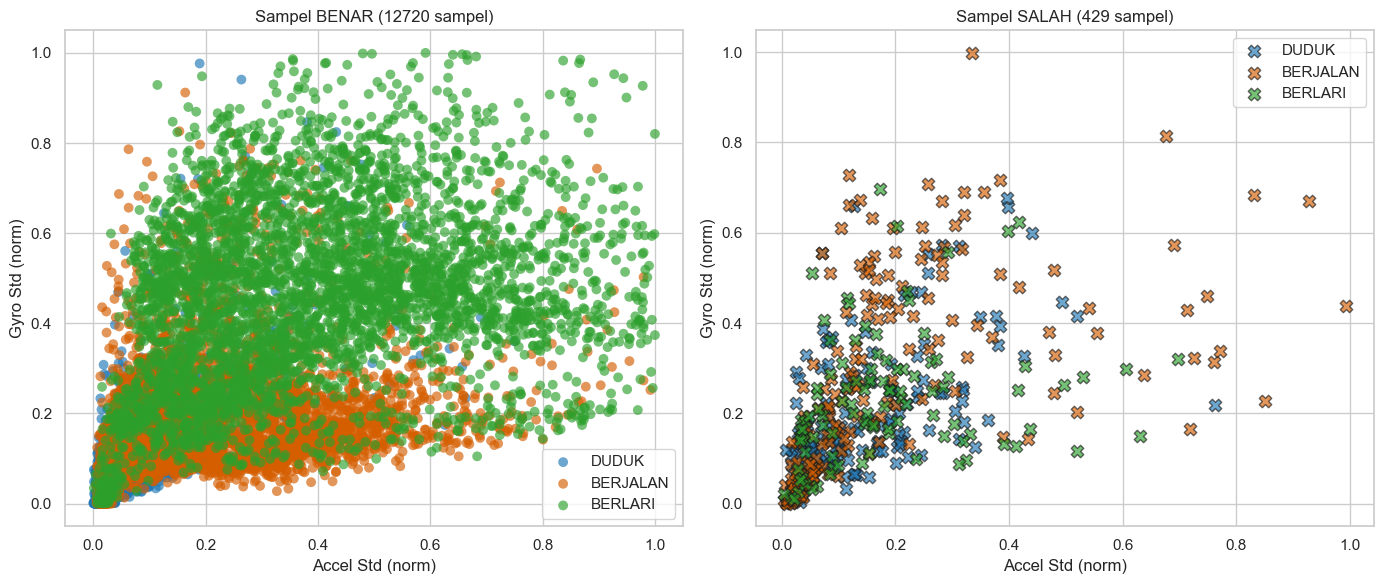

In [6]:
COLORS = ['#1F77B4','#D55E00','#2CA02C']
cmap   = dict(zip(CLASSES, COLORS))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (ax, title, subset) in enumerate([
    (axes[0], 'Sampel BENAR', df[df['correct']]),
    (axes[1], 'Sampel SALAH', df[~df['correct']])
]):
    for cls in CLASSES:
        s = subset[subset[TARGET]==cls]
        ax.scatter(s['accel_stddev'], s['gyro_stddev'],
                   c=cmap[cls], label=cls, alpha=0.65,
                   edgecolors='k' if i==1 else 'none',
                   s=50 if i==0 else 80, marker='o' if i==0 else 'X')
    ax.set_xlabel('Accel Std (norm)'); ax.set_ylabel('Gyro Std (norm)')
    ax.set_title(f'{title} ({len(subset)} sampel)')
    ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/error_analysis_3fitur.png', dpi=150); plt.show()

## 6. Visualisasi BPM vs Aktivitas (Scatter)

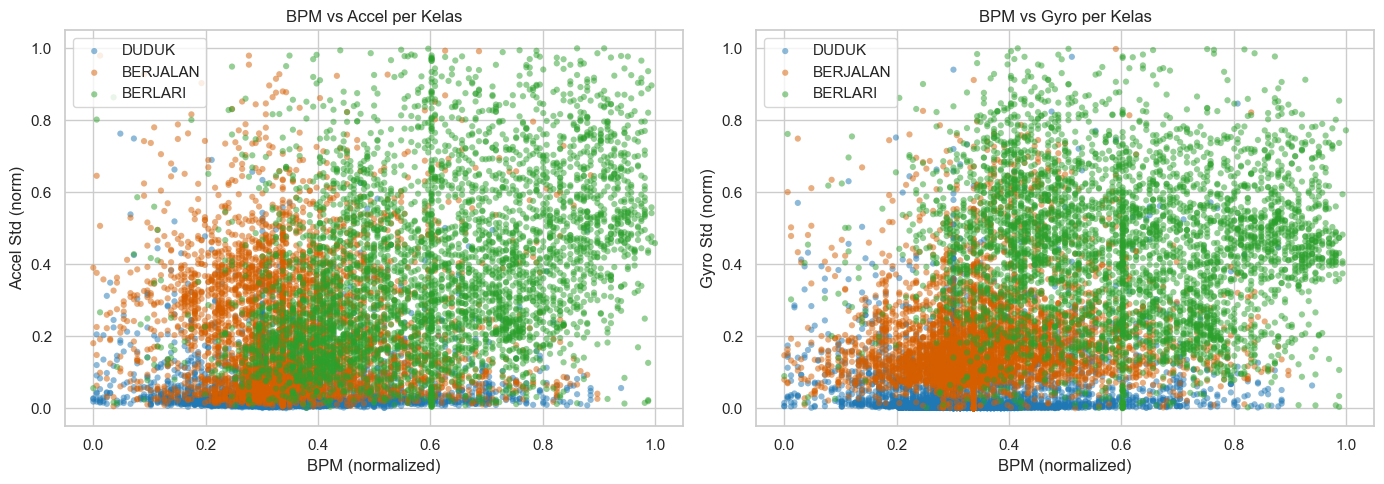

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ['#1F77B4','#D55E00','#2CA02C']
cmap   = dict(zip(CLASSES, COLORS))

# BPM filled vs Accel (normalized)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    axes[0].scatter(s['bpm_filled'], s['accel_stddev'], c=color, label=cls,
                    alpha=0.5, s=20, edgecolors='none')
axes[0].set_xlabel('BPM (normalized)'); axes[0].set_ylabel('Accel Std (norm)')
axes[0].set_title('BPM vs Accel per Kelas'); axes[0].legend()

# BPM filled vs Gyro (normalized)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    axes[1].scatter(s['bpm_filled'], s['gyro_stddev'], c=color, label=cls,
                    alpha=0.5, s=20, edgecolors='none')
axes[1].set_xlabel('BPM (normalized)'); axes[1].set_ylabel('Gyro Std (norm)')
axes[1].set_title('BPM vs Gyro per Kelas'); axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/bpm_scatter_3fitur.png', dpi=150); plt.show()

## 7. Learning Curve

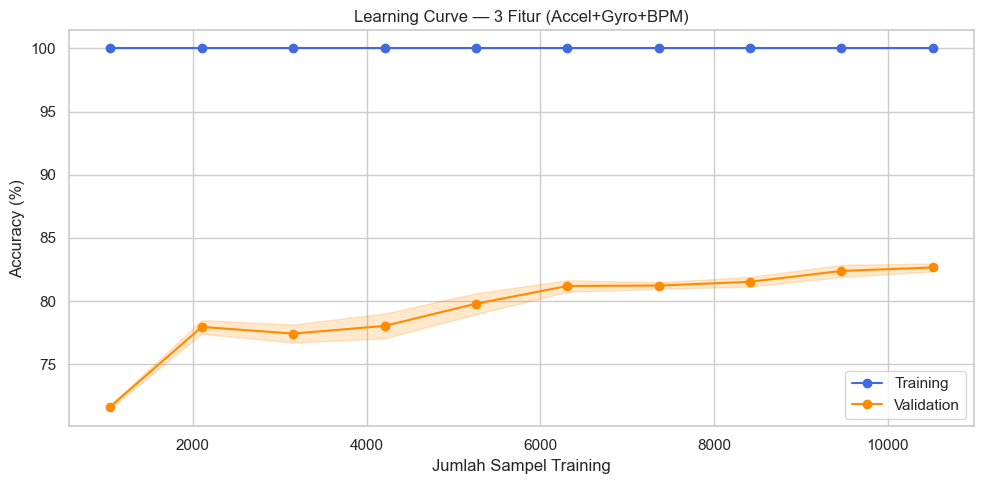

Gap train-val: 17.33%
⚠  Kemungkinan overfitting.


In [8]:
from sklearn.model_selection import learning_curve
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y_true, cv=kfold,
    train_sizes=np.linspace(0.1,1.0,10), scoring='accuracy', n_jobs=-1
)
tm, ts = train_scores.mean(1), train_scores.std(1)
vm, vs = val_scores.mean(1),   val_scores.std(1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, tm*100, 'o-', color='royalblue', label='Training')
plt.fill_between(train_sizes, (tm-ts)*100, (tm+ts)*100, alpha=0.2, color='royalblue')
plt.plot(train_sizes, vm*100, 'o-', color='darkorange', label='Validation')
plt.fill_between(train_sizes, (vm-vs)*100, (vm+vs)*100, alpha=0.2, color='darkorange')
plt.xlabel('Jumlah Sampel Training'); plt.ylabel('Accuracy (%)')
plt.title('Learning Curve — 3 Fitur (Accel+Gyro+BPM)')
plt.legend(); plt.tight_layout()
plt.savefig('../data/processed/learning_curve_3fitur.png', dpi=150); plt.show()

gap = tm[-1] - vm[-1]
print(f'Gap train-val: {gap*100:.2f}%')
if gap > 0.10: print('⚠  Kemungkinan overfitting.')
elif vm[-1] < 0.85: print('⚠  Akurasi rendah — tambah data.')
else: print('✅ Model terlihat baik.')

## 8. Ringkasan Akhir

In [9]:
print('='*57)
print('  RINGKASAN UJI COBA MODEL')
print('='*57)
print(f'  Algoritma : KNN (K={model.n_neighbors}, metric={model.metric})')
print(f'  Fitur     : {FEATURES}')
print(f'  Kelas     : {CLASSES}')
print(f'  Dataset   : {len(df)} sampel')
print(f'  Akurasi   : {acc*100:.2f}%')
print(f'  BPM med   : {bpm_medians}')
print('='*57)

  RINGKASAN UJI COBA MODEL
  Algoritma : KNN (K=18, metric=euclidean)
  Fitur     : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
  Kelas     : ['DUDUK', 'BERJALAN', 'BERLARI']
  Dataset   : 13149 sampel
  Akurasi   : 96.74%
  BPM med   : {'DUDUK': 80, 'BERJALAN': 86, 'BERLARI': 130, '_global': 93}
